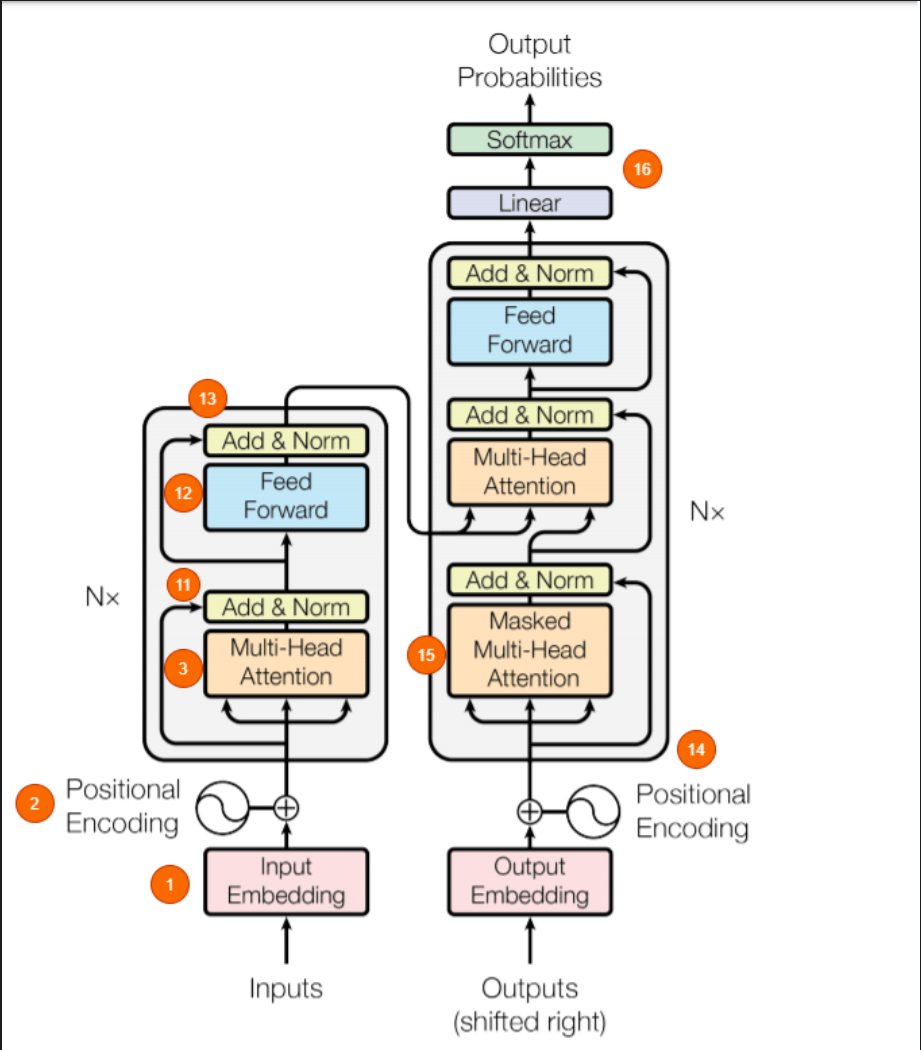

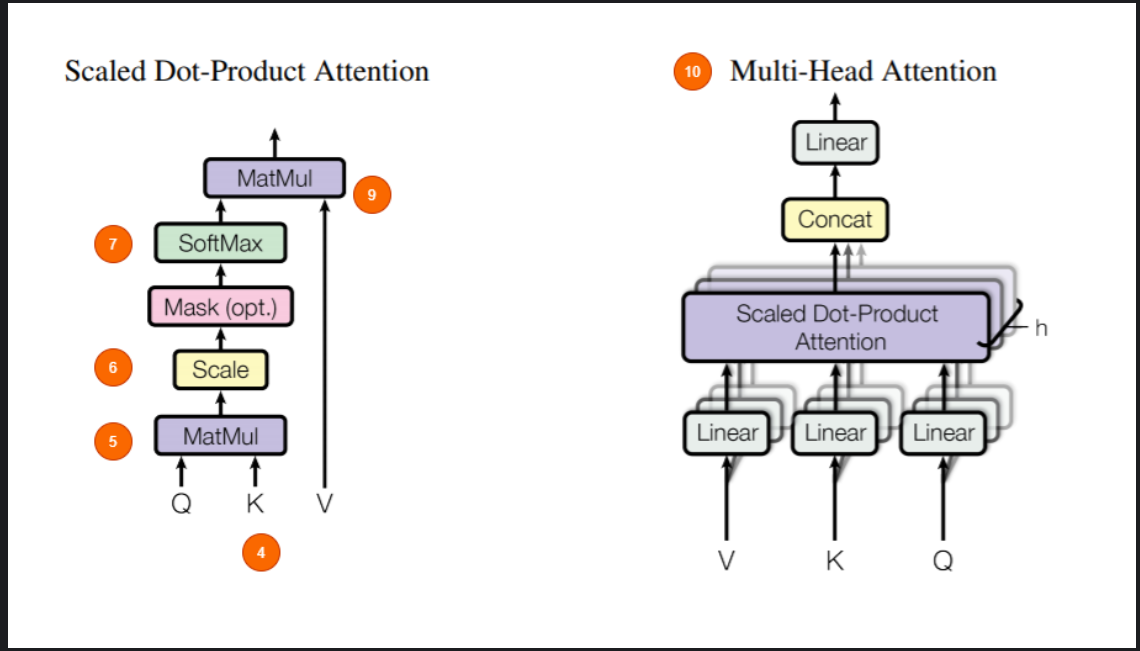

Transformer 模型彻底革新了我们所熟知的自然语言处理 (NLP) 技术。它们最初问世时便打破了多项 NLP 记录，并引领了当时的 NLP 技术发展潮流。如今，Transformer 模型已成为现代 NLP 任务的事实标准，与 LSTM 和 GRU 等上一代模型相比，性能提升显著。

迄今为止，对 NLP 领域产生重大影响的论文当属《Attention is all you need》（注意力机制就是你所需要的一切）一文。Transformer 架构正是在这篇论文中提出的。

当时用于序列和 NLP 任务的现有模型大多基于循环神经网络 (RNN)。这些网络的不足之处在于无法捕捉长期依赖关系。

LSTM 和 GRU 作为 RNN 的变体，虽然能够捕捉这些依赖关系，但其能力也存在局限性。

因此，Transformer 的主要设计理念在于摆脱这种循环论证的束缚，同时尽可能地捕捉所有依赖关系，更准确地说是全局依赖关系。是的，Transformer 的参考窗口是全范围的。这是通过一种称为自注意力机制（多头）的注意力机制变体实现的，这对Transformer模型的成功至关重要。Transformer模型的另一个优势是其高度并行化。

(1) 输入数据首先被嵌入到一个向量中。嵌入层帮助我们获取每个词的学习向量表示。

(2) 在下一阶段，位置编码被注入到输入嵌入中。这是因为Transformer模型并不知道作为输入传递的序列（例如一个句子）的顺序。

(3) 现在，多头注意力机制开始发挥作用。

(4) 多头注意力机制由三个可学习的向量组成：查询向量、键向量和值向量。据称，其动机源于信息检索，在信息检索中，用户进行搜索（查询），搜索引擎将用户的查询与键进行比较，并返回一个值。

(5) 将 Q 和 K 表示进行点积矩阵乘法，生成一个得分矩阵，该矩阵表示一个词需要关注其他词的程度。得分越高，表示关注度越高，反之亦然。

(6) 然后，根据 Q 和 K 向量的维度对得分矩阵进行缩放。这样做是为了确保梯度更加稳定，因为乘法运算可能会导致梯度爆炸。

（我们将在解码器部分讨论掩码部分）

(7) 接下来，对得分矩阵进行 softmax 操作，将注意力得分转换为概率。显然，高分值会被提升，低分值会被降低。这确保模型能够准确判断应该关注哪些词。

(8) 然后，将包含概率的结果矩阵与值向量相乘。这将使模型学习到的高概率得分词更加重要。低分值词将被有效地掩盖，变得无关紧要。

(9) 最后，将 Q、K 和 V 向量的拼接输出输入到线性层进行进一步处理。

(10) 对序列中的每个词执行自注意力机制。由于自注意力机制彼此独立，因此可以使用多个自注意力模块副本同时处理所有词，从而实现多头处理。

(11) 然后，将输出值向量连接起来，并添加到来自输入层的残差连接中，最后将得到的表示传递给 LayerNorm 进行归一化。（残差连接有助于梯度在网络中流动，而 LayerNorm 有助于略微缩短训练时间并稳定网络。）

(12) 接下来，将输出传递给逐点前馈网络，以获得更丰富的表示。

(13) 再次对输出进行 LayerNorm 归一化，并添加来自上一层的残差。

注：编码器部分到此结束，相信我，这些内容足以让你完全理解 Vision Transformer。解码器部分与编码层非常相似，因此我将主要留给你自己去理解。

(14) 编码器的输出以及来自前几个时间步/词的输入（如果有）被送入解码器，解码器的输出经过掩码多头注意力机制处理，然后与编码器的输出一起送入下一个注意力层。

(15) 掩码多头注意力机制是必要的，因为网络在解码过程中不应该看到序列中后续出现的词，以确保没有信息泄露。这是通过掩码得分矩阵中序列中后续词的条目来实现的。序列中当前词和前一个词的得分加 1，后续词的得分加 -inf。这确保了在执行 softmax 操作以获得概率时，序列中后续词的得分会被淹没为 0，而其余的得分则被保留。

(16) 这里也存在残差连接，以改善梯度流动。最后，输出被发送到线性层并进行 softmax 操作以获得概率形式的输出。

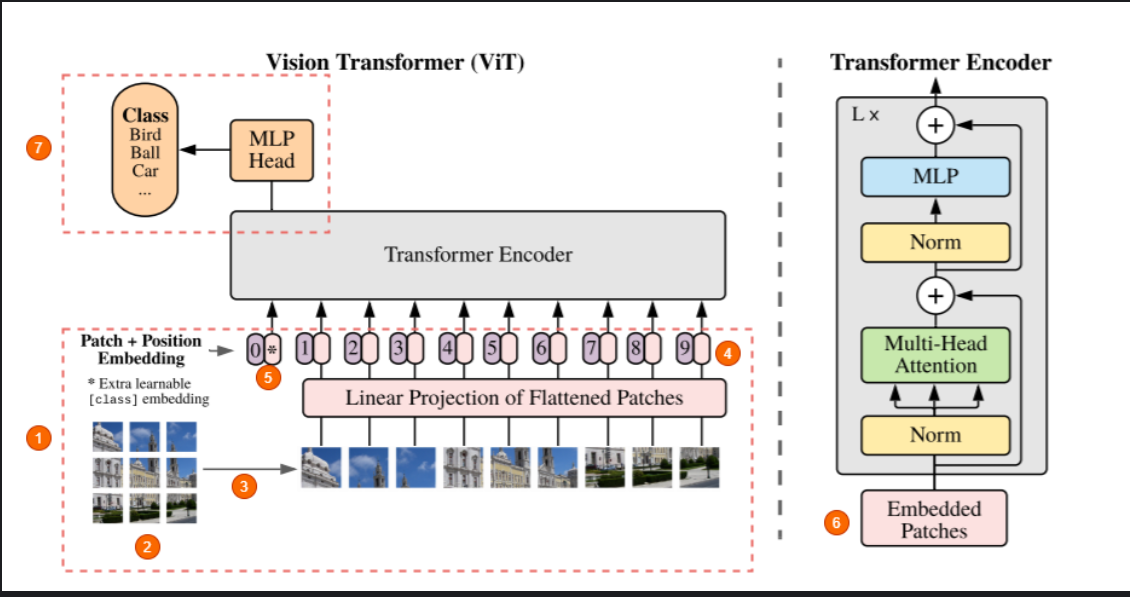

 ## 视觉变换器是如何工作的？¶

既然我们已经从宏观层面了解了变换器的内部工作原理，现在终于可以深入探讨视觉变换器了。

将变换器应用于图像始终是一个挑战，原因如下：

与文字/句子/段落不同，图像包含的信息量要大得多，这些信息基本上以像素的形式存在。

即使使用当前的硬件，也很难关注图像中的每个像素。

因此，一种流行的替代方案是使用局部注意力机制。

事实上，卷积神经网络（CNN）通过卷积运算实现了类似的功能，感受野会随着模型层数的增加而增大。但由于变换器本身的特性，其计算成本始终高于 CNN。当然，我们也知道 CNN 对计算机视觉领域的当前发展做出了多么巨大的贡献。

谷歌的研究人员在他们的论文中提出了一种不同的方法，这可能是计算机视觉领域的下一个重大突破。它们表明，对卷积神经网络（CNN）的依赖可能不再必要。那么，让我们深入了解一下视觉Transformer。

(1) 它们仅使用了Transformer的编码器部分，但区别在于它们将图像输入网络的方式。

(2) 它们将图像分割成固定大小的图像块。因此，这些图像块可以是16x16或32x32（如论文中所述）。图像块越多，训练这些网络就越简单，因为图像块本身会越来越小。因此，我们在标题中看到“一张图胜过16x16个字”。

(3) 然后，这些图像块被展开（展平）并发送到网络中进行进一步处理。

(4) 与神经网络不同，这里的模型完全不知道样本在序列中的位置，每个样本都是输入图像中的一个图像块。因此，图像连同位置嵌入向量一起被输入到编码器中。需要注意的是，位置嵌入也是可学习的，因此实际上无需输入与位置相关的硬编码向量。

(5) 与 BERT 类似，开头也有一个特殊的标记。

(6) 每个图像块首先被展开（展平）成一个大向量，并与一个同样可学习的嵌入矩阵相乘，从而生成嵌入块。这些嵌入块与位置嵌入向量组合，并输入到 Transformer 中。

注意：从这里开始，所有步骤都与标准 Transformer 相同。

(7) 唯一的区别在于，编码器的输出不是通过解码器，而是直接输入到前馈神经网络以获得分类输出。

需要注意的是：

该论文几乎完全忽略了卷积。

然而，他们使用了 ViT 的几种变体，其中使用了图像块的卷积嵌入。但这似乎对性能影响不大。

截至撰写本文时，Vision Transformer 在 ImageNet 图像分类基准测试中名列前茅。

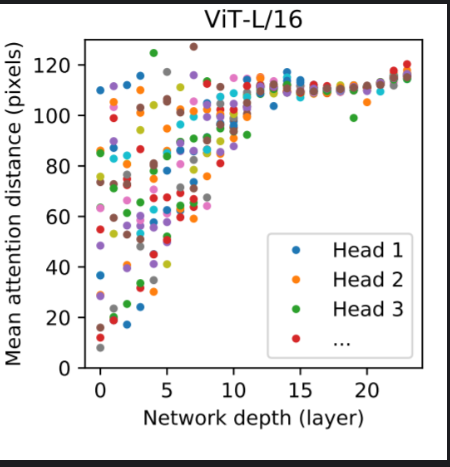

上图表明，Transformer 从网络起始层开始就能关注到相距甚远的区域，这与初始感受野有限的 CNN 相比，是 Transformer 的一项显著优势。